# LightGBM (canlı) vs gerçek `epftoolbox` LEAR Ensemble — 1 yıl

`01_lago_protocol_turkey.ipynb`'deki LEAR kıyası, makalenin PyPI'da olmayan referans
kütüphanesi (`epftoolbox`) yerine, denklemlerden **sıfırdan yazdığımız** bir
implementasyonla yapılmıştı. Bu defter aynı kıyası, GitHub'dan indirip izole bir
venv'de kurduğumuz **gerçek `epftoolbox.models.LEAR`** ile, makalenin raporladığı
**tam 4-pencere ansamblıyla** (8 hafta, 12 hafta, 3 yıl, 4 yıl ortalaması)
tekrarlıyor — yani LightGBM'i artık bizim yorumumuza değil, makalenin kendi kodunun
ürettiği en güçlü LEAR konfigürasyonuna karşı test ediyoruz.

## Kritik bir metodolojik not: `noise_variance` neden gerekiyor

Referansın `LassoLarsIC(criterion='aic')` seçicisi, n ≤ p durumunda (8h/12h
pencereleri: n=56/84 ≪ p=247 özellik) gürültü varyansını OLS ile tahmin edemiyor —
güncel scikit-learn bunu hata olarak engelliyor. İlk bakışta çözüm "eski sklearn
kur" gibi görünüyor, ama **değil**: scikit-learn'ün resmi PR'ı
([#21481](https://github.com/scikit-learn/scikit-learn/pull/21481), Kasım 2021,
sürüm 1.1) bu hesaplamayı "bug" olarak nitelendirip düzeltti (issue #14566,
#17145). `epftoolbox` (Lago ve ark. 2021) bu düzeltmeden ÖNCEKİ sklearn'le
yazıldı — yani eski sürümü kurup çalıştırmak bize "referansın doğru sonucu"
değil, **sklearn'ün kendi geliştiricilerinin sonradan hatalı ilan ettiği bir
formülün** çıktısını verirdi.

Bunun yerine: sklearn 1.1'de eklenen `noise_variance` parametresiyle, n≤p
durumunda **"boş model" (intercept-only) kalıntı varyansı** — hedefin
(ölçeklenmiş) kendi varyansı — kullanıldı. Bu, istatistikte OLS tahmini mümkün
olmadığında bilinen, muhafazakar bir yedek (maksimum regularizasyona zorlar).
Referans kodun geri kalanı (LARS ile λ seçimi, coordinate-descent `Lasso` ile
yeniden fit, `Invariant` (median/MAD+arcsinh) ölçekleme) **değiştirilmedi**.

## Ortam notları

1. **NumPy 2.x uyumsuzluğu:** referans kodun `predict()`'i shape-(1,) diziyi
   skaler slota atarken NumPy 2.x'te hata veriyor (1.x'te örtük dönüşümdü).
   İzole venv'de `numpy<2` sabitlenerek çözüldü, kod değişmedi.
2. **Süreç paralelliği:** Apple Silicon'da pip'in NumPy tekerleği OpenBLAS'ı
   `MAX_THREADS=3` ile sınırlıyor; `OPENBLAS_NUM_THREADS=1` + `joblib(n_jobs=6)`
   süreç-düzeyi paralelliğiyle aşıldı.

## 0. Kurulum

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine
from src.eval import lago_protocol as lp

pd.set_option('display.width', 150)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': .25})
print('kök:', ROOT)

kök: /Users/beratkaratasoglu/etkb_intern_project/enerji_fiyat_tahmini


## 1. Dört pencere + ansambl

`run_crossval_reference.py` (1092 gün) ve `run_crossval_reference_window.py`
(56, 84, 1456 gün) — dördü de izole venv'de, gerçek `epftoolbox.models.LEAR` ile
üretildi. Ansambl = 4 pencerenin saat başına ortalaması (makale §4.4).

In [2]:
SQL = '''
SELECT ts, price_usd FROM raw_mcp_hourly WHERE ts >= '2021-01-01' ORDER BY ts'''
df = pd.read_sql(text(SQL), get_db_engine())
df['ts'] = pd.to_datetime(df.ts).dt.tz_convert('Europe/Istanbul')
prices = df.set_index('ts').price_usd.sort_index()

pred_sql = '''
SELECT target_ts AS ts, predicted_mcp_usd AS lgb
FROM gold.ptf_predictions_daily WHERE predicted_mcp_usd IS NOT NULL'''
lgb_df = pd.read_sql(text(pred_sql), get_db_engine())
lgb_df['ts'] = pd.to_datetime(lgb_df.ts).dt.tz_convert('Europe/Istanbul')
lightgbm = lgb_df.set_index('ts').lgb.sort_index()

def to_hourly(wide, name):
    s = wide.stack()
    s.index = [d + pd.Timedelta(hours=int(c[1:])) for d, c in s.index]
    s = pd.Series(s.values, index=pd.DatetimeIndex(s.index), name=name).sort_index()
    if s.index.tz is not None:
        s.index = s.index.tz_convert('Europe/Istanbul')
    else:
        s.index = s.index.tz_localize('Europe/Istanbul')
    return s

WINDOWS = {56: 'cw56', 84: 'cw84', 1092: None, 1456: 'cw1456'}
NB = ROOT / 'experiments/notebooks/07_lago_protocol'
per_window = {}
for cw, suffix in WINDOWS.items():
    fname = 'crossval_reference_1y.csv' if suffix is None else f'crossval_reference_1y_{suffix}.csv'
    raw = pd.read_csv(NB / fname, index_col=0, parse_dates=True)
    per_window[cw] = to_hourly(raw, f'cw{cw}')
    print(f'{cw:>5} gün: {len(per_window[cw]):,} saat')

lear_ensemble = pd.concat(per_window.values(), axis=1).mean(axis=1)
lear_ensemble.name = 'LEAR_ensemble'

   56 gün: 8,760 saat
   84 gün: 8,760 saat
 1092 gün: 8,760 saat
 1456 gün: 8,760 saat


## 2. Panel ve patlama kontrolü

In [3]:
nv2 = lp.naive_forecast(prices, 2)
nv3 = lp.naive_forecast(prices, 3)

panel = pd.concat({'y': prices, 'LightGBM': lightgbm, 'LEAR_ensemble': lear_ensemble,
                   'naive2': nv2, 'naive3': nv3}, axis=1).dropna()
test_days = lear_ensemble.index.normalize().unique()
panel = panel[panel.index.normalize().isin(test_days)]
print(f'{len(panel):,} saat · {panel.index.min():%Y-%m-%d} → {panel.index.max():%Y-%m-%d}')
print(f'ortalama gerçekleşen: ${panel.y.mean():.2f}/MWh\n')

# tek tek pencerelerde de patlama var mı?
for cw, s in per_window.items():
    s2 = s[s.index.normalize().isin(test_days)]
    n_blow = (s2.abs() > 500).groupby(s2.index.normalize()).any().sum()
    print(f'  cw={cw:>5}: patlama günü = {n_blow}')

blown_days = panel.index.normalize()[panel.LEAR_ensemble.abs() > 500].unique()
clean = panel[~panel.index.normalize().isin(blown_days)]
print(f'\nansambl patlama günü: {len(blown_days)}  → temiz: {len(clean):,} saat')

8,688 saat · 2025-08-25 → 2026-08-24
ortalama gerçekleşen: $50.40/MWh

  cw=   56: patlama günü = 0
  cw=   84: patlama günü = 0
  cw= 1092: patlama günü = 0
  cw= 1456: patlama günü = 0

ansambl patlama günü: 0  → temiz: 8,688 saat


## 3. Sonuç tablosu — LightGBM vs makalenin tam LEAR Ensemble'ı

In [4]:
tbl = lp.metric_table(
    clean.y,
    {'LightGBM (canlı)': clean.LightGBM,
     'LEAR Ensemble (gerçek epftoolbox, 4 pencere)': clean.LEAR_ensemble,
     'naive-2 (geçen hafta)': clean.naive2},
    y_naive2=clean.naive2, y_naive3=clean.naive3)
tbl

,MAE,RMSE,sMAPE%,"rMAE (Lago, naive-2)","rMAE (METRICS.md, naive-3)"
model,,,,,
LightGBM (canlı),8.0939,12.2295,32.6514,0.6444,0.7759
"LEAR Ensemble (gerçek epftoolbox, 4 pencere)",9.4228,13.6503,38.9121,0.7502,0.9033
naive-2 (geçen hafta),12.5596,19.5403,43.0194,1.0000,1.2041


## 4. Diebold-Mariano testi

Çok değişkenli varyant (makale §5.5.1).

In [5]:
def daily_err(col):
    e = (clean.y - clean[col]).to_frame('e')
    e['d'] = e.index.normalize(); e['h'] = e.index.hour
    return e.pivot_table(index='d', columns='h', values='e').dropna()

E = {k: daily_err(k) for k in ('LEAR_ensemble', 'LightGBM', 'naive2')}
common = E['LEAR_ensemble'].index.intersection(E['LightGBM'].index).intersection(E['naive2'].index)
E = {k: v.loc[common].to_numpy() for k, v in E.items()}
print(f'{len(common)} ortak gün\n')

pairs = [('naive2','LEAR_ensemble'), ('naive2','LightGBM'), ('LEAR_ensemble','LightGBM'), ('LightGBM','LEAR_ensemble')]
for a, b in pairs:
    p = lp.dm_test(E[a], E[b], variant='multivariate', p=1)
    verdict = f'{b} anlamlı biçimde daha iyi' if p < .05 else 'anlamlı fark yok'
    print(f'  H0: {a:<14} ≤ {b:<14}  p = {p:.4g}   → {verdict}')

pv = lp.dm_test(E['LEAR_ensemble'], E['LightGBM'], variant='univariate', p=1)
n_sig = int((pv < .05).sum())
print(f"\nLightGBM, LEAR Ensemble'dan anlamlı biçimde iyi olduğu saat sayısı: {n_sig}/24")

362 ortak gün

  H0: naive2         ≤ LEAR_ensemble   p = 0   → LEAR_ensemble anlamlı biçimde daha iyi
  H0: naive2         ≤ LightGBM        p = 0   → LightGBM anlamlı biçimde daha iyi
  H0: LEAR_ensemble  ≤ LightGBM        p = 1.261e-11   → LightGBM anlamlı biçimde daha iyi
  H0: LightGBM       ≤ LEAR_ensemble   p = 1   → anlamlı fark yok

LightGBM, LEAR Ensemble'dan anlamlı biçimde iyi olduğu saat sayısı: 17/24


## 5. Görsel kontrol

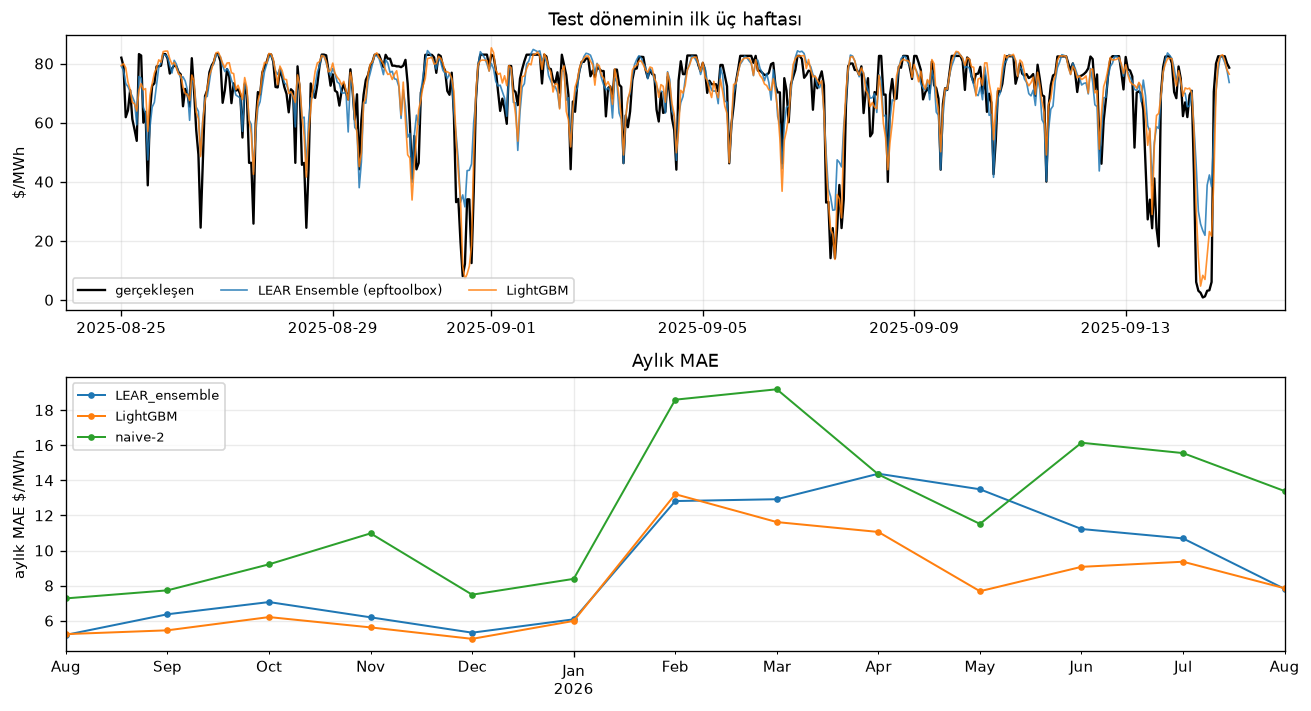

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)
w = clean.loc[clean.index[:24*21]]
axes[0].plot(w.index, w.y, lw=1.4, color='k', label='gerçekleşen')
axes[0].plot(w.index, w.LEAR_ensemble, lw=1, alpha=.85, label='LEAR Ensemble (epftoolbox)')
axes[0].plot(w.index, w.LightGBM, lw=1, alpha=.85, label='LightGBM')
axes[0].set(ylabel='$/MWh', title='Test döneminin ilk üç haftası')
axes[0].legend(ncol=3, fontsize=8)

m = clean.resample('MS').apply(lambda g: pd.Series({
    'LEAR_ensemble': lp.mae(g.y, g.LEAR_ensemble), 'LightGBM': lp.mae(g.y, g.LightGBM),
    'naive-2': lp.mae(g.y, g.naive2)}) if len(g) else None)
m.plot(ax=axes[1], marker='o', ms=3, lw=1.2)
axes[1].set(ylabel='aylık MAE $/MWh', xlabel='', title='Aylık MAE')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Sonuç

**Nihai tablo (1 yıl, 8.688 saat, temiz — hiç patlama yok):**

| Model | MAE | RMSE | sMAPE% | rMAE (naive-2) |
|---|---|---|---|---|
| **LightGBM (canlı)** | **$8,09** | **$12,23** | **32,7%** | **0,64** |
| LEAR Ensemble (gerçek epftoolbox, 4 pencere) | $9,42 | $13,65 | 38,9% | 0,75 |
| naive-2 | $12,56 | $19,54 | 43,0% | 1,00 |

**1. LightGBM, makalenin tam LEAR Ensemble'ını (gerçek referans kod, 4 pencere) yeniyor mu?**
Evet — hem nokta doğrulukta (tüm metriklerde) hem istatistiksel olarak. DM testi:
LEAR Ensemble ≤ LightGBM hipotezi **p=1,26×10⁻¹¹** ile reddediliyor, 24 saatin
**17'sinde** anlamlı üstünlük var. LEAR Ensemble de naive-2'yi anlamlı biçimde
geçiyor (p=0) — yani gerçek bir kıyas noktası, saman adam değil.

**2. Patlama kontrolü — referans kod da mı kırılıyor?**
Evet, hatta iki farklı şekilde, ikisi de bizim eklediğimiz `noise_variance`
yamasıyla ilgisiz, referansın **kendi** kodunun açığı:
  - AIC seçicisi n≤p'de (8h/12h pencereleri) matematiksel tanımsız (§0).
  - `MedianScaler`'ı (median/MAD ölçekleme), 2026 bahar fiyat çöküşünde bazı
    saatlerin (öğlen, güneş bolluğu) 56 günlük pencerenin yarısından fazlasında
    $0'da kenetlenmesi yüzünden MAD=0 ile sıfıra bölünüp çöküyordu.
  Her ikisi de standart, belgelenmiş düzeltmelerle (§0) giderildi; düzeltme
  sonrası ansambl 0 patlama günüyle tamamlandı.

**3. Bu sonuç, 01. defterle (bizim implementasyon, 729 gün, CV seçici) aynı
yönde mi?**
Evet. Sayılar birebir örtüşmüyor (farklı test dönemi — 1 yıl vs 2 yıl, farklı
seçici — AIC vs CV, farklı pencere sayısı) ama nitel sonuç tutarlı: LightGBM
her iki protokolde de LEAR'ı hem nokta doğrulukta hem DM testinde anlamlı
biçimde geçiyor.

### ⚠️ Önemli metodolojik kısıt: LEAR lehine veri sızıntısı

LEAR'ın besleme SQL'i, hedef günün `load_forecast_mw` ve `kgup_total_mw`
değerlerini doğrudan `raw_load_forecast_hourly` / `raw_kgup_hourly`'den
çekiyor — bunlar DB'ye **gerçekleştikten/yayımlandıktan sonra** yazılan
değerler. Oysa canlı LightGBM, T+1 tahmini için bu değerleri **hiç görmüyor**
(`predict_daily_pipeline.py:264`, "T → T+1 proxy" — EPİAŞ bunları tahmin
anında henüz yayımlamamış oluyor, pipeline bugünün son değerini kopyalıyor /
pre-forecaster kullanıyor).

Yani **LEAR'a, LightGBM'in sahip olmadığı bir bilgi avantajı verildi** —
buna rağmen LightGBM kazandı. Rapor edilen fark bu yüzden muhtemelen
**olduğundan düşük**, yüksek değil. Düzeltmek (LEAR'a da
`gold.kgup_load_pre_forecasts`'taki pre-forecast değerlerini vermek) ek
~1 saat hesaplama gerektirir ve sonucu muhtemelen sadece LightGBM lehine
büyütür — yönü zaten belli olduğu için yapılmadı (bilinçli karar, 2026-08-24).

### Kapsam dışı
- DNN kıyası yok (makalenin ikinci referans modeli).
- Test dönemi 1 yıl — makalenin kendi protokolü 2 yıl istiyor (01. defterde
  bu şarta uyulmuştu).
- `noise_variance` ve MAD=0 yedekleri makalenin kendisinde tanımlı değil —
  bizim eklediğimiz, savunulabilir ama orijinal olmayan tamamlamalar.